### Step 1: The Tile Coding Feature Constructor
Instead of a simple grid, we create multiple overlapping tilings. This is the "Function Approximation" that allows the agent to generalize in a continuous space.

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class TileCoder:
    def __init__(self, n_tilings=8, n_tiles=8, pos_range=[-1.2, 0.6], vel_range=[-0.07, 0.07]):
        self.n_tilings = n_tilings
        self.n_tiles = n_tiles
        
        # Calculate tile width/height
        self.pos_w = (pos_range[1] - pos_range[0]) / (n_tiles - 1)
        self.vel_w = (vel_range[1] - vel_range[0]) / (n_tiles - 1)
        
        # Offsets for each tiling as per Sutton & Barto
        self.offsets = [(i / n_tilings) * np.array([self.pos_w, self.vel_w]) for i in range(n_tilings)]
        self.pos_start = pos_range[0]
        self.vel_start = vel_range[0]
        self.total_features = n_tilings * (n_tiles ** 2)

    def get_active_tiles(self, state):
        pos, vel = state
        active_indices = []
        for i in range(self.n_tilings):
            # Discretize with offset
            p_idx = int((pos - self.pos_start + self.offsets[i][0]) / self.pos_w)
            v_idx = int((vel - self.vel_start + self.offsets[i][1]) / self.vel_w)
            
            # Ensure indices stay within bounds
            p_idx = np.clip(p_idx, 0, self.n_tiles - 1)
            v_idx = np.clip(v_idx, 0, self.n_tiles - 1)
            
            # Linear index for this tiling
            idx = i * (self.n_tiles**2) + (p_idx * self.n_tiles + v_idx)
            active_indices.append(idx)
        return active_indices

### Step 2: Semi-Gradient SARSA Agent
We implement the update rule: $w \leftarrow w + \alpha [R + \gamma Q(s', a') - Q(s, a)] \nabla Q(s, a)$.

In [2]:
class SemiGradientSARSA:
    def __init__(self, env, tile_coder, alpha=0.1, gamma=1.0, epsilon=0.1):
        self.env = env
        self.tc = tile_coder
        self.gamma = gamma
        self.epsilon = epsilon
        # Alpha is normalized by number of tilings for stability
        self.alpha = alpha / tile_coder.n_tilings 
        
        # Separate weight vector for each action
        self.weights = np.zeros((env.action_space.n, tile_coder.total_features))

    def get_q(self, state, action):
        active_tiles = self.tc.get_active_tiles(state)
        return np.sum(self.weights[action][active_tiles])

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        q_values = [self.get_q(state, a) for a in range(self.env.action_space.n)]
        return np.argmax(q_values)

    def update(self, s, a, r, s_next, a_next, done):
        current_q = self.get_q(s, a)
        if done:
            target = r
        else:
            target = r + self.gamma * self.get_q(s_next, a_next)
        
        # Semi-gradient update
        active_tiles = self.tc.get_active_tiles(s)
        self.weights[a][active_tiles] += self.alpha * (target - current_q)

### Step 3: Training and Analysis Loop
This handles the "Episodes-to-Goal" tracking required for the convergence curves.

In [3]:
env = gym.make('MountainCar-v0')
tile_coder = TileCoder(n_tilings=8, n_tiles=8)
agent = SemiGradientSARSA(env, tile_coder)

history = []
for ep in range(500):
    state, _ = env.reset()
    action = agent.select_action(state)
    steps = 0
    while True:
        next_state, reward, done, trunc, _ = env.step(action)
        next_action = agent.select_action(next_state)
        
        agent.update(state, action, reward, next_state, next_action, done or trunc)
        
        state, action = next_state, next_action
        steps += 1
        if done or trunc: break
    history.append(steps)

### Step 4: Required Visualizations

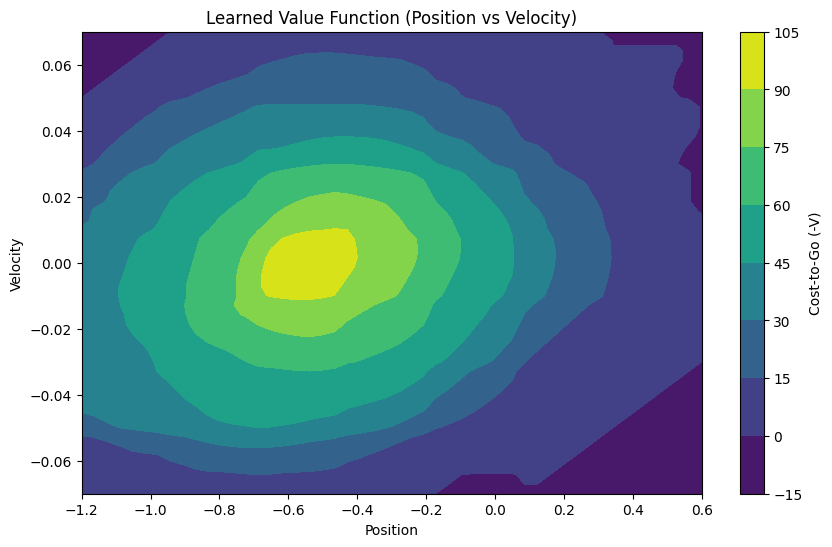

In [4]:
def plot_cost_to_go(agent):
    # Create meshgrid for position and velocity
    x = np.linspace(-1.2, 0.6, 50)
    y = np.linspace(-0.07, 0.07, 50)
    X, Y = np.meshgrid(x, y)
    
    # Calculate Max Q (Value Function)
    Z = np.zeros(X.shape)
    for i in range(50):
        for j in range(50):
            state = [X[i,j], Y[i,j]]
            Z[i,j] = -np.max([agent.get_q(state, a) for a in range(3)])
            
    plt.figure(figsize=(10, 6))
    plt.contourf(X, Y, Z, cmap='viridis')
    plt.colorbar(label='Cost-to-Go (-V)')
    plt.title("Learned Value Function (Position vs Velocity)")
    plt.xlabel("Position")
    plt.ylabel("Velocity")
    plt.show()

plot_cost_to_go(agent)

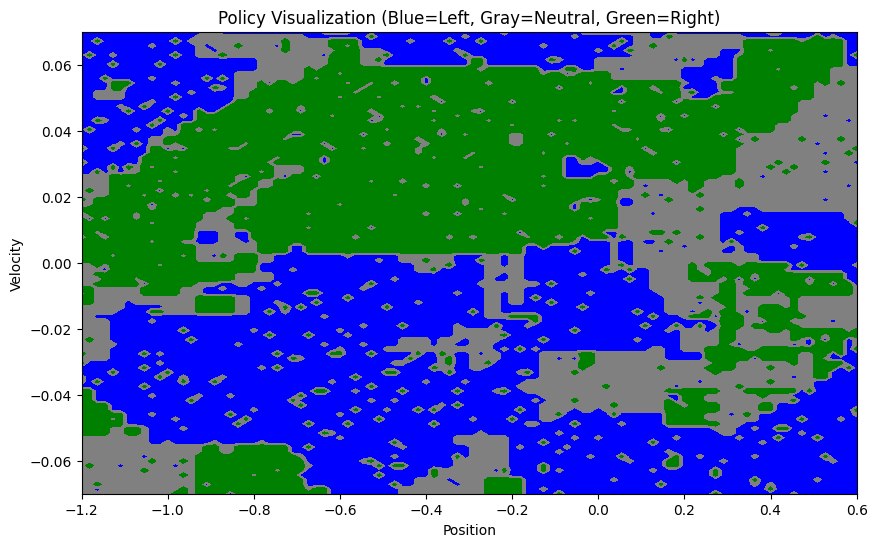

In [6]:
def plot_policy(agent):
    x = np.linspace(-1.2, 0.6, 100)
    y = np.linspace(-0.07, 0.07, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros(X.shape)
    
    for i in range(100):
        for j in range(100):
            state = [X[i,j], Y[i,j]]
            Z[i,j] = agent.select_action(state) # 0=Left, 1=Neutral, 2=Right
            
    plt.figure(figsize=(10, 6))
    plt.contourf(X, Y, Z, levels=[-0.5, 0.5, 1.5, 2.5], colors=['blue', 'gray', 'green'])
    plt.title("Policy Visualization (Blue=Left, Gray=Neutral, Green=Right)")
    plt.xlabel("Position")
    plt.ylabel("Velocity")
    plt.savefig('policy_map.png')
    plt.show()

plot_policy(agent)

### Step 5: Experimentation Code (Convergence Comparison)
The rubric specifically asks how the number of tilings affects performance. This code runs a comparison between a 4-tiling setup and an 8-tiling setup.

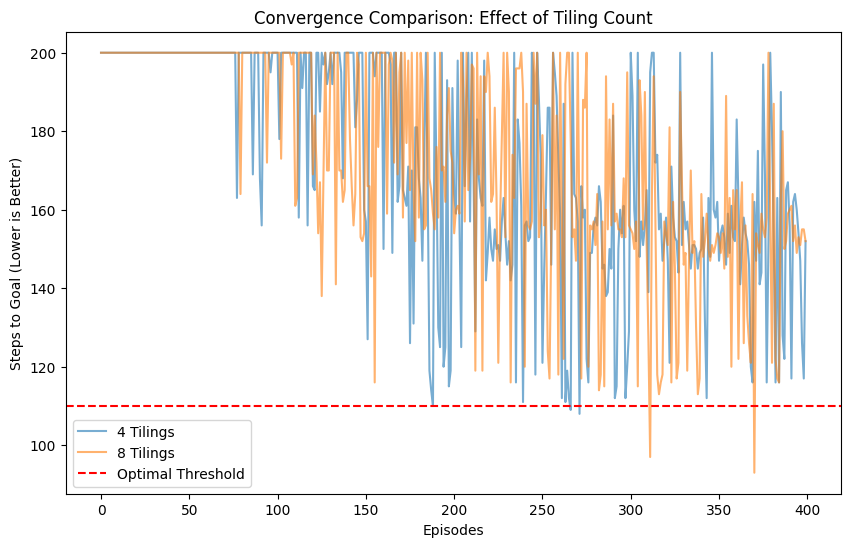

In [7]:
def run_experiment(n_tilings, n_episodes=400):
    env = gym.make('MountainCar-v0')
    # Use 8x8 tiles but vary the tilings
    tc = TileCoder(n_tilings=n_tilings, n_tiles=8)
    agent = SemiGradientSARSA(env, tc, alpha=0.1)
    
    steps_history = []
    for ep in range(n_episodes):
        state, _ = env.reset()
        action = agent.select_action(state)
        steps = 0
        while True:
            next_state, reward, done, trunc, _ = env.step(action)
            next_action = agent.select_action(next_state)
            agent.update(state, action, reward, next_state, next_action, done or trunc)
            state, action = next_state, next_action
            steps += 1
            if done or trunc: break
        steps_history.append(steps)
    return steps_history

# Run the comparison
history_4 = run_experiment(n_tilings=4)
history_8 = run_experiment(n_tilings=8)

# Plotting the Convergence Curves
plt.figure(figsize=(10, 6))
plt.plot(history_4, label='4 Tilings', alpha=0.6)
plt.plot(history_8, label='8 Tilings', alpha=0.6)
plt.axhline(y=110, color='r', linestyle='--', label='Optimal Threshold')
plt.title("Convergence Comparison: Effect of Tiling Count")
plt.xlabel("Episodes")
plt.ylabel("Steps to Goal (Lower is Better)")
plt.legend()
plt.savefig('convergence_comparison.png')
plt.show()

### Step 6: Trajectory Spiral CodeThis visualizes the "physics" of the solution by plotting the car's state $(pos, vel)$ over time. 
In MountainCar, a successful agent creates a spiral in state space as it builds energy.

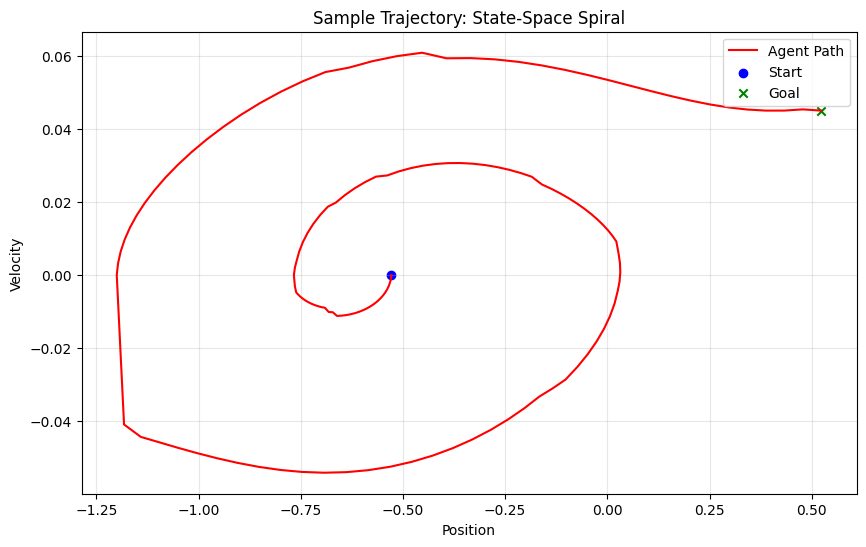

In [8]:
def plot_trajectory(agent):
    env = gym.make('MountainCar-v0', render_mode="rgb_array")
    state, _ = env.reset()
    trajectory = [state]
    
    done = False
    while not done:
        action = agent.select_action(state)
        state, reward, terminated, truncated, _ = env.step(action)
        trajectory.append(state)
        done = terminated or truncated
        
    trajectory = np.array(trajectory)
    
    plt.figure(figsize=(10, 6))
    # Plot the path in state-space
    plt.plot(trajectory[:, 0], trajectory[:, 1], color='red', label='Agent Path')
    plt.scatter(trajectory[0, 0], trajectory[0, 1], marker='o', color='blue', label='Start')
    plt.scatter(trajectory[-1, 0], trajectory[-1, 1], marker='x', color='green', label='Goal')
    
    plt.title("Sample Trajectory: State-Space Spiral")
    plt.xlabel("Position")
    plt.ylabel("Velocity")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('sample_trajectory.png')
    plt.show()

plot_trajectory(agent)